```
# author: puru panta (purupanta@uky.edu)
# date: 11/30/2024
# filename: PredictMLDL_Stacked
```



**STEP1: Install and Import libraries required**

In [54]:
!pip install --upgrade tf-keras
!pip install --upgrade tensorflow
!pip install --upgrade scikit-learn imbalanced-learn
!pip install xlsxwriter
!pip install --upgrade scikeras # Upgrade scikeras

  Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)


In [55]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
import matplotlib.pyplot as plt


from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, fbeta_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import make_classification

In [56]:
# Mounting google drive if it is already not mounted
def LoadGoogleDrive(googleDriveDir):
  # Link Google Drive
  import os
  # Check if Google Drive is already mounted
  if not os.path.exists(googleDriveDir + "/MyDrive"):
      print("Mounting Google Drive...")
      from google.colab import drive
      drive.mount(googleDriveDir)
  else:
      print("Google Drive is already mounted!")

**STEP2: Load google-drive, and data**

In [57]:
# Mount the google drive
googleDriveFolder = "/content/drive"
LoadGoogleDrive(googleDriveFolder)
# ip_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/ip_data/hints6_public.xlsx"
ip_file_path = googleDriveFolder + "/MyDrive/Colab Notebooks/P_HINTS6/op_data/op_hints6_public_cleaned.xlsx"
ip_sheet_name = "hints6_public_cleaned" # "hints6_public_cleaned_diabetic" # "hints6_public"
colsToLoad = ["FreqGoProvider", "GeneralHealth", "Deaf", "MedConditions_Diabetes","MedConditions_HighBP", "MedConditions_HeartCondition","MedConditions_LungDisease", "MedConditions_Depression","AverageSleepNight","AverageTimeSitting", "EverHadCancer", "Age", "BirthGender", "BMI", "smokeStat", "PHQ4", "WeeklyMinutesModerateExercise", "AvgDrinksPerWeek"];

print("Ip File Path: " + ip_file_path + "\t SheetName: " + ip_sheet_name)

# Loading cleaded excel data
df_orig = pd.read_excel(ip_file_path, sheet_name=ip_sheet_name, usecols=colsToLoad)

# One-hot encode the relevant categorical variables
cols_to_encode = ['GeneralHealth', 'BirthGender', 'FreqGoProvider', 'smokeStat']
df_encoded = pd.get_dummies(df_orig, columns=cols_to_encode, drop_first=True)

df = df_encoded.copy()


predictors = df.drop(columns=['MedConditions_HeartCondition']).columns
target = df['MedConditions_HeartCondition'].name

print(f"df_orig.shape: {df_orig.shape}")

Google Drive is already mounted!
Ip File Path: /content/drive/MyDrive/Colab Notebooks/P_HINTS6/op_data/op_hints6_public_cleaned.xlsx	 SheetName: hints6_public_cleaned
df_orig.shape: (4875, 18)


In [58]:
# Determine which column needs One Hot Encoding
# Select non-numeric (object or category) columns
non_numeric_cols = df.select_dtypes(include=['object', 'category']).columns

# Find columns with more than 2 unique values
ohe_columns = [col for col in non_numeric_cols if df[col].nunique() > 2]

print("Columns to One-Hot Encode:", ohe_columns)


Columns to One-Hot Encode: []


**STEP3: Train-test split Scale, SMOTEENN**

In [59]:
from collections import Counter
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import SMOTE

def TrainTestSplit(df):
  # AllCols = ["FreqGoProvider", "GeneralHealth", "Deaf", "MedConditions_Diabetes", "MedConditions_HighBP", "MedConditions_HeartCondition", "MedConditions_LungDisease", "MedConditions_Depression", "AverageSleepNight", "AverageTimeSitting", "EverHadCancer", "Age", "BirthGender", "BMI", "smokeStat", "PHQ4", "WeeklyMinutesModerateExercise", "AvgDrinksPerWeek"];

  # Define features (X) and target (y)
  X = df.drop(columns=['MedConditions_HeartCondition'])
  y = df['MedConditions_HeartCondition']

  # Convert categorical variables to numerical using one-hot encoding

  # Perform train-test split (80% train, 20% test)
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42, stratify=y
  )
  return X_train, X_test, y_train, y_test

# Step 2: Scale features using StandardScaler
def ScaleTrainData(X_train, X_test):
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)   # Fit ONLY on training data
  X_test_scaled = scaler.transform(X_test)         # Use same scaler on test data
  return X_train_scaled, X_test_scaled, scaler

# Step 3: Apply SMOTE only to training data
def ApplySMOTE(X_train, y_train):
    sm = SMOTE(random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)

    # Count original and resampled target classes
    original_counts = Counter(y_train)
    resampled_counts = Counter(y_res)

    print(f"Original dataset shape: total = (1: {original_counts.get(1, 0)}, 0: {original_counts.get(0, 0)})")
    print(f"Resampled dataset shape: total = (1: {resampled_counts.get(1, 0)}, 0: {resampled_counts.get(0, 0)})")

    return X_res, y_res

def ApplySMOTEENN(X_train, y_train):
    sm = SMOTEENN(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Count original and resampled target classes
    original_counts = Counter(y_train)
    resampled_counts = Counter(y_train_res)

    print(f"Original dataset shape: total = (1: {original_counts.get(1, 0)}, 0: {original_counts.get(0, 0)})")
    print(f"Resampled dataset shape: total = (1: {resampled_counts.get(1, 0)}, 0: {resampled_counts.get(0, 0)})")

    return X_train_res, y_train_res


# Step 5: Apply ApplyADASYN only to training data
def ApplyADASYN(X_train, y_train):
    adasyn = ADASYN(random_state=42)
    X_res, y_res = adasyn.fit_resample(X_train, y_train)

    # Count class occurrences before and after resampling
    original_counts = Counter(y_train)
    resampled_counts = Counter(y_res)

    print(f"Original training set shape: total = (1: {original_counts.get(1, 0)}, 0: {original_counts.get(0, 0)})")
    print(f"Resampled training set shape: total = (1: {resampled_counts.get(1, 0)}, 0: {resampled_counts.get(0, 0)})")

    return X_res, y_res

# Step 6: Apply ApplyBorderlineSMOTE only to training data
def ApplyBorderlineSMOTE(X_train, y_train, kind='borderline-1'):
    sm = BorderlineSMOTE(kind=kind, random_state=42)
    X_res, y_res = sm.fit_resample(X_train, y_train)

    # Count class occurrences before and after resampling
    original_counts = Counter(y_train)
    resampled_counts = Counter(y_res)

    print(f"Original training set shape: total = (1: {original_counts.get(1, 0)}, 0: {original_counts.get(0, 0)})")
    print(f"Resampled training set shape: total = (1: {resampled_counts.get(1, 0)}, 0: {resampled_counts.get(0, 0)})")

    return X_res, y_res

In [60]:
# Count occurrences of each class
count_1 = (df['MedConditions_HeartCondition'] == 1).sum()
count_0 = (df['MedConditions_HeartCondition'] == 0).sum()

print(f"Count of heart condition = 1: {count_1}")
print(f"Count of heart condition = 0: {count_0}")


Count of heart condition = 1: 456
Count of heart condition = 0: 4419


In [61]:
X_train, X_test, y_train, y_test = TrainTestSplit(df)

**STEP4: Data Clean AND adding a data-sheet**

In [62]:
X_train_res, y_train_res = ApplySMOTEENN(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplyBorderlineSMOTE(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplyADASYN(X_train.copy(), y_train.copy())
# X_train_res, y_train_res = ApplySMOTE(X_train.copy(), y_train.copy())

Original dataset shape: total = (1: 365, 0: 3535)
Resampled dataset shape: total = (1: 3273, 0: 2229)


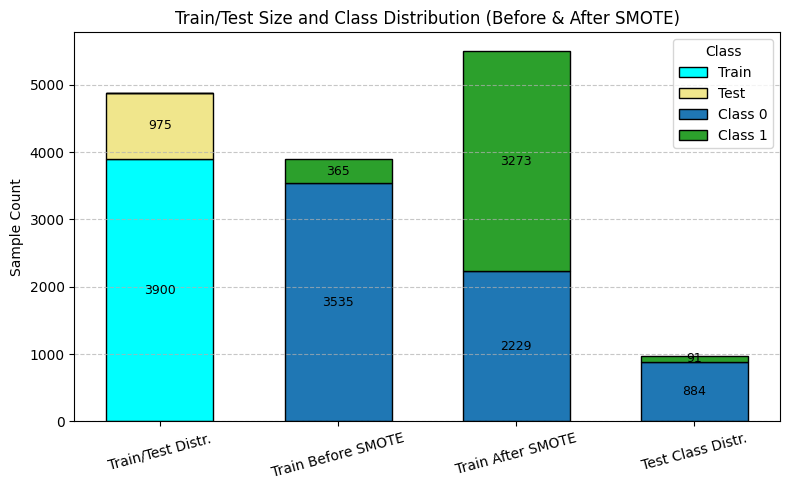

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data for plotting
plot_data = {
    'Train/Test Distr.': {
        'Train': len(y_train),
        'Test': len(y_test)
    },
    'Train Before SMOTE': {
        'Class 0': (y_train == 0).sum(),
        'Class 1': (y_train == 1).sum()
    },
    'Train After SMOTE': {
        'Class 0': (y_train_res == 0).sum(),
        'Class 1': (y_train_res == 1).sum()
    },
    'Test Class Distr.': {
        'Class 0': (y_test == 0).sum(),
        'Class 1': (y_test == 1).sum()
    }
}

# Define custom colors
class_colors = {
    'Class 0': '#1f77b4',  # blue
    'Class 1': '#2ca02c',  # green
    'Train': '#00FFFF',    # cyan
    'Test': '#F0E68C'      # dim yellow
}

# Convert to DataFrame
df_plot = pd.DataFrame(plot_data).T.fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(df_plot.index))
bar_width = 0.6
bottom = np.zeros(len(x))

# Plot each class/group
for cls in df_plot.columns:
    heights = df_plot[cls].values

    if np.all(heights == 0):
        continue  # Skip entire column if all zeros

    bars = ax.bar(
        x, heights, bottom=bottom, width=bar_width,
        label=cls, edgecolor='black', color=class_colors.get(cls, 'gray')
    )

    # Add number to each non-zero segment
    for i, height in enumerate(heights):
        if height > 0:
            ax.text(
                x[i], bottom[i] + height / 2, str(int(height)),
                ha='center', va='center', fontsize=9, color='black'
            )

    bottom += heights

# Axes and layout
ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=15)
ax.set_title('Train/Test Size and Class Distribution (Before & After SMOTE)')
ax.set_ylabel('Sample Count')
ax.legend(title='Class', loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [64]:
# Step 4: If needed, reshape the target arrays
y_train = y_train.to_numpy().ravel() if hasattr(y_train, 'to_numpy') else y_train.ravel()
y_test = y_test.to_numpy().ravel() if hasattr(y_test, 'to_numpy') else y_test.ravel()

In [65]:
# Train/Test assignments
X_train = X_train_res.copy();
y_train = y_train_res.copy();
X_test = X_test.copy();
y_test = y_test.copy();

In [66]:
X_train, X_test, scaler = ScaleTrainData(X_train.copy(), X_test.copy())

**STEP8: Prediction Starts**

**1. Stacked Model**

In [67]:
# Train/Test assignments
X_train_stacked = X_train.copy()
y_train_stacked = y_train.copy()
X_test_stacked = X_test.copy()
y_test_stacked = y_test.copy()

In [68]:
from tabpfn import TabPFNClassifier
import torch  # Needed for torch.cuda.is_available()

# Initialize TabPFN
tabpfn_model = TabPFNClassifier(device="cuda" if torch.cuda.is_available() else "cpu")
# Train the model
tabpfn_model.fit(X_train_stacked, y_train_stacked)

TabPFNClassifier(device='cuda')

In [69]:
from lightgbm import LGBMClassifier

# Step 1: Class balance calculation
neg, pos = (df['MedConditions_HeartCondition'] == 0).sum(), (df['MedConditions_HeartCondition'] == 1).sum()
scale_pos_weight = neg / pos

# Step 2: Define parameter grids for each model
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10]
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly']
}

param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

param_grid_gbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [scale_pos_weight]
}

param_grid_lgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    'max_depth': [-1, 5, 10],
    'scale_pos_weight': [scale_pos_weight]
}

# Step 3: Grid Search for each model

# Random Forest
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_rf, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_stacked, y_train_stacked)
best_rf = rf_grid.best_estimator_

# Logistic Regression
lr_grid = GridSearchCV(
    LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42),
    param_grid_lr, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_stacked, y_train_stacked)
best_lr = lr_grid.best_estimator_

# SVM
svm_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=42),
    param_grid_svm, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
svm_grid.fit(X_train_stacked, y_train_stacked)
best_svm = svm_grid.best_estimator_

# KNN
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
knn_grid.fit(X_train_stacked, y_train_stacked)
best_knn = knn_grid.best_estimator_

# Gradient Boosting
gbm_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gbm, scoring='f1', cv=3, n_jobs=-1, verbose=1
)
gbm_grid.fit(X_train_stacked, y_train_stacked)
best_gbm = gbm_grid.best_estimator_

# XGBoost
# xgb_grid = GridSearchCV(
    # XGBClassifier(eval_metric='logloss', random_state=42),
    # param_grid_xgb, scoring='f1', cv=5, n_jobs=-1, verbose=1
# )
# xgb_grid.fit(X_train_stacked, y_train_stacked)
# best_xgb = xgb_grid.best_estimator_

# LightGBM
# lgb_grid = GridSearchCV(
    # LGBMClassifier(objective='binary', random_state=42),
    # param_grid_lgb, scoring='f1', cv=5, n_jobs=-1, verbose=1
# )
# lgb_grid.fit(X_train_stacked, y_train_stacked)
# best_lgb = lgb_grid.best_estimator_

# Step 4: Print best models
print("Best Random Forest:", best_rf)
print("Best Logistic Regression:", best_lr)
print("Best SVM:", best_svm)
print("Best KNN:", best_knn)
print("Best Gradient Boosting:", best_gbm)
# print("Best XGBoost:", best_xgb)
# print("Best LightGBM:", best_lgb)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Random Forest: RandomForestClassifier(class_weight='balanced', random_state=42)
Best Logistic Regression: LogisticRegression(C=10, class_weight='balanced', random_state=42,
                   solver='liblinear')
Best SVM: SVC(C=1, class_weight='balanced', kernel='poly', probability=True,
    random_state=42)
Best KNN: KNeighborsClassifier(n_neighbors=7, weights='distance')
Best Gradient Boosting: GradientBoostingClassifier(max_depth=5, random_state=42)


In [70]:
# Define base learners
base_models = [
    ('rf', best_rf),
    ('lr', best_lr),
    ('svm', best_svm),
    ('knn', best_knn),
    ('gbm', best_gbm),
    ('tabpfn', tabpfn_model)
]

# Meta-model
meta_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# # Meta-model
# meta_model = RandomForestClassifier(n_estimators=200, max_depth=20, class_weight='balanced', random_state=42)

# meta_model = XGBClassifier(scale_pos_weight=neg / pos, eval_metric='logloss', random_state=42)

# from sklearn.ensemble import GradientBoostingClassifier
# meta_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)


stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=False  # Exclude raw features in the meta-learner
    # n_jobs=-1
)

Best threshold for max F1 (calibrated): 0.37
Total execution time: 50.67 seconds
Stacked Model Accuracy (threshold=0.37): 0.86
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.94      0.90      0.92       884
     Class 1       0.30      0.41      0.35        91

    accuracy                           0.86       975
   macro avg       0.62      0.66      0.63       975
weighted avg       0.88      0.86      0.87       975

AUC-ROC (calibrated): 0.72


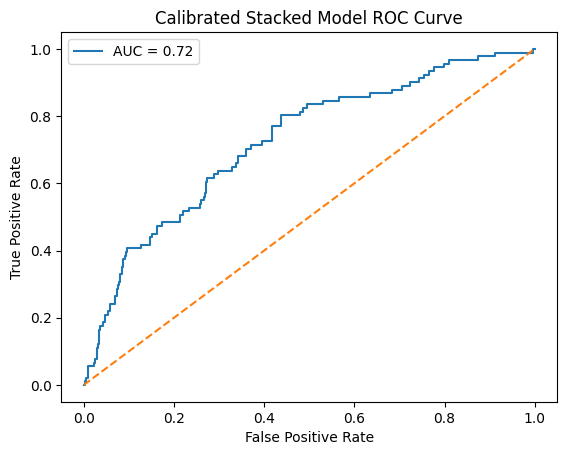

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)


# --- Step 1: Define StratifiedKFold ---
# skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Train and calibrate the stacked model
calibrated_model = CalibratedClassifierCV(estimator=stacked_model, method='sigmoid', cv=3)
# calibrated_model = CalibratedClassifierCV(estimator=stacked_model, method='isotonic', cv=3)


# Start timing
start_time = time.time()

calibrated_model.fit(X_train_stacked, y_train_stacked)

# Predict calibrated probabilities
y_prob_calibrated = calibrated_model.predict_proba(X_test_stacked)[:, 1]


# Find the best threshold for maximum F1-score
prec, rec, thresh = precision_recall_curve(y_test_stacked, y_prob_calibrated)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-6)  # Avoid division by zero
best_thresh = thresh[np.argmax(f1_scores)]
print(f"Best threshold for max F1 (calibrated): {best_thresh:.2f}")

# Apply best threshold
y_pred_thresh = (y_prob_calibrated >= best_thresh).astype(int)

# Calculate execution time
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")

# Accuracy with thresholded predictions
accuracy_stacked = accuracy_score(y_test_stacked, y_pred_thresh)
print(f"Stacked Model Accuracy (threshold={best_thresh:.2f}): {accuracy_stacked:.2f}")

# Classification report
target_names = ['Class 0', 'Class 1']
report_stacked = classification_report(y_test_stacked, y_pred_thresh, target_names=target_names)
print("Classification Report:\n", report_stacked)

# AUC-ROC (threshold-independent)
auc_roc_stacked = roc_auc_score(y_test_stacked, y_prob_calibrated)
print(f"AUC-ROC (calibrated): {auc_roc_stacked:.2f}")

# ROC Curve
fpr_stacked, tpr_stacked, thresholds_stacked = roc_curve(y_test_stacked, y_prob_calibrated)
plt.plot(fpr_stacked, tpr_stacked, label=f'AUC = {auc_roc_stacked:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Calibrated Stacked Model ROC Curve')
plt.legend()
plt.show()
